# Промежуточная аттестация №1

## Сбор и анализ данных для проекта

**База данных:** `banking` — операции розничного банка: клиенты, счета, карты,
кредиты, платежи по кредитам, транзакции.

---

## 1. Бизнес-задача

Банк несёт потери от просроченных платежей по кредитам: это и прямые издержки
на работу с задолженностью, и замороженные резервы, и стоимость привлечения
клиента, который в итоге оказался проблемным.

Сейчас решение о выдаче принимается по формальным правилам: проверяется
занятость, доход и отсутствие текущей задолженности. Правила одинаковы для всех
и не различают заёмщиков внутри одобренной группы.

**Формулировка цели:**

> Снизить долю кредитов с просроченными платежами с текущих 20,6% до 17%
> в течение года, не сокращая объём выдач более чем на 5%.

Ограничение на объём выдач здесь обязательно. Без него задача решается
тривиально и вредно для бизнеса: достаточно резко ужесточить условия
и выдавать меньше кредитов.

## 2. Задача машинного обучения

**Бинарная классификация.** Для заявки на кредит предсказать вероятность того,
что заёмщик допустит хотя бы один просроченный платёж в течение срока кредита.

Почему именно классификация, а не регрессия: банку на этапе решения нужен ответ
«рискованный или нет» для сортировки заявок, а не точное число дней просрочки.
Кроме того, величина просрочки в данных не зафиксирована — есть только статус
платежа.

**Практическое применение результата:** заявки с высокой предсказанной
вероятностью не отклоняются автоматически, а направляются на ручное
рассмотрение либо получают скорректированные условия — меньшую сумму или
более короткий срок.

## 3. Целевая переменная и признаки

**Целевая переменная:** `has_late_payment` — принимает значение 1, если хотя бы
один платёж по кредиту получил статус `LATE` или `MISSED`, иначе 0.

**Признаки** сгруппированы по источнику:

| Группа | Признаки |
|---|---|
| Параметры кредита | сумма, ставка, срок, тип продукта, оценка ежемесячного платежа |
| Заёмщик | годовой доход, статус занятости, отрасль, возраст |
| Долговая нагрузка | отношение суммы к доходу, отношение платежа к месячному доходу |
| История в банке | стаж клиента, число счетов, число карт |

**Принципиальное ограничение — защита от утечки целевой переменной.**
Все признаки рассчитываются только по данным, доступным банку на дату выдачи
кредита. Запись о занятости берётся та, что действовала на эту дату, счета и
карты считаются только открытые до неё. Фактическое поведение по платежам
в признаки не попадает: иначе модель выучила бы ответ вместо того, чтобы
научиться его предсказывать.

Данные собраны представлением `v_loan_risk` (файл `Аттестация1_VIEW.sql`)
и выгружены в CSV.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

%matplotlib inline

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)

print("pandas:", pd.__version__)

pandas: 3.0.3


## 4. Загрузка данных из представления

In [2]:
df = pd.read_csv("data/loan_risk.csv")

print("Размер выборки:", df.shape)
print()
print("Доля кредитов с просрочкой: {:.2f}%".format(df["has_late_payment"].mean() * 100))
print()
df.head()

Размер выборки: (2477, 20)

Доля кредитов с просрочкой: 20.63%



,loan_id,customer_id,has_late_payment,principal_amount,interest_rate,term_months,loan_type,loan_product,monthly_payment_est,annual_income,employment_status,industry_name,debt_to_income,payment_to_income,borrower_age_years,client_tenure_years,accounts_count,cards_count,disbursement_date,payments_total
0,1,6,0,9359671.45,13.4203,120,MORTGAGE,Mortgage,182671.93,2154655.92,Employed,Construction,4.3439,1.0174,24.3,0.07,1,0,2025-09-11,3
1,4,22,0,1088267.74,24.0639,12,PERSONAL,Personal Loan,112512.28,7672814.40,Employed,Public Sector,0.1418,0.1760,63.7,0.03,1,1,2025-11-25,1
2,5,23,0,369542.04,17.2866,60,PERSONAL,Personal Loan,11482.47,2618852.76,Employed,Energy,0.1411,0.0526,33.8,0.02,1,1,2025-08-26,4
3,6,27,0,6715317.59,10.9088,120,MORTGAGE,Mortgage,117007.69,1285964.04,Employed,Healthcare,5.2220,1.0919,53.8,0.08,1,1,2025-04-13,8
4,7,28,0,296854.98,18.0720,12,PERSONAL,Personal Loan,29208.55,2732976.60,Self-employed,Retail,0.1086,0.1282,45.3,0.03,1,0,2025-07-23,5


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2477 entries, 0 to 2476
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   loan_id              2477 non-null   int64  
 1   customer_id          2477 non-null   int64  
 2   has_late_payment     2477 non-null   int64  
 3   principal_amount     2477 non-null   float64
 4   interest_rate        2477 non-null   float64
 5   term_months          2477 non-null   int64  
 6   loan_type            2477 non-null   str    
 7   loan_product         2477 non-null   str    
 8   monthly_payment_est  2477 non-null   float64
 9   annual_income        2477 non-null   float64
 10  employment_status    2477 non-null   str    
 11  industry_name        2382 non-null   str    
 12  debt_to_income       2469 non-null   float64
 13  payment_to_income    2469 non-null   float64
 14  borrower_age_years   2477 non-null   float64
 15  client_tenure_years  2477 non-null   float64
 16 

## 5. Разведочный анализ данных

### 5.1. Баланс классов

Первое, что нужно проверить в задаче классификации, — насколько классы
сбалансированы. От этого зависит и выбор метрики, и способ обучения.

In [4]:
balance = df["has_late_payment"].value_counts().sort_index()
balance.index = ["Без просрочки", "С просрочкой"]

print(balance.to_string())
print()
print("Доля положительного класса: {:.2f}%".format(df["has_late_payment"].mean() * 100))
print()
print("Что это значит для метрики:")
print("  модель, всегда отвечающая «просрочки не будет», даст точность",
      "{:.1f}%".format((1 - df['has_late_payment'].mean()) * 100))
print("  при этом она не найдёт ни одного проблемного заёмщика,")
print("  поэтому accuracy как метрика непригодна — нужны recall и ROC-AUC")

Без просрочки    1966
С просрочкой      511

Доля положительного класса: 20.63%

Что это значит для метрики:
  модель, всегда отвечающая «просрочки не будет», даст точность 79.4%
  при этом она не найдёт ни одного проблемного заёмщика,
  поэтому accuracy как метрика непригодна — нужны recall и ROC-AUC


### 5.2. Описательные статистики числовых признаков

In [5]:
numeric_cols = [
    "principal_amount", "interest_rate", "term_months", "monthly_payment_est",
    "annual_income", "debt_to_income", "payment_to_income",
    "borrower_age_years", "client_tenure_years", "accounts_count", "cards_count",
]

df[numeric_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
principal_amount,2477.0,2769276.64,2994147.86,100915.73,557503.57,1042061.94,4960516.99,9980470.05
interest_rate,2477.0,17.36,4.43,10.01,13.28,17.60,21.16,25.00
term_months,2477.0,104.62,96.45,12.00,36.00,60.00,180.00,300.00
monthly_payment_est,2477.0,60029.42,42831.62,3286.39,26474.55,47523.97,86879.93,200164.66
annual_income,2477.0,2296362.46,1339002.50,0.00,1419009.48,1964831.28,2762145.96,8476093.68
debt_to_income,2469.0,1.59,3.08,0.02,0.28,0.56,2.04,86.02
payment_to_income,2469.0,0.41,0.57,0.01,0.15,0.28,0.51,13.37
borrower_age_years,2477.0,44.09,12.02,16.90,34.50,43.50,53.30,79.30
client_tenure_years,2477.0,0.10,0.08,0.00,0.03,0.08,0.12,0.49
accounts_count,2477.0,1.11,0.32,1.00,1.00,1.00,1.00,3.00


### 5.3. Пропуски

In [6]:
na = df.isna().sum()
na = na[na > 0].sort_values(ascending=False)

if len(na):
    report = pd.DataFrame({"пропусков": na, "доля, %": (na / len(df) * 100).round(2)})
    print(report.to_string())
else:
    print("Пропусков нет")

                   пропусков  доля, %
industry_name             95     3.84
debt_to_income             8     0.32
payment_to_income          8     0.32


### 5.4. Поиск некорректных значений

Пропуски — это только та часть проблем, которую видно сразу. Гораздо опаснее
значения, которые формально заполнены, но физически или логически невозможны.
Проверим признаки на такие случаи.

In [7]:
checks = {
    "возраст заёмщика меньше 18 лет": (df["borrower_age_years"] < 18).sum(),
    "возраст заёмщика больше 80 лет": (df["borrower_age_years"] > 80).sum(),
    "годовой доход равен нулю": (df["annual_income"] == 0).sum(),
    "долговая нагрузка выше 10": (df["debt_to_income"] > 10).sum(),
    "платёж превышает месячный доход": (df["payment_to_income"] > 1).sum(),
    "отрицательный стаж в банке": (df["client_tenure_years"] < 0).sum(),
    "сумма кредита не положительна": (df["principal_amount"] <= 0).sum(),
}

for name, count in checks.items():
    mark = "  <-- требует решения" if count > 0 else ""
    print(f"{name:34} {count:4}{mark}")

возраст заёмщика меньше 18 лет        6  <-- требует решения
возраст заёмщика больше 80 лет        0
годовой доход равен нулю              8  <-- требует решения
долговая нагрузка выше 10            29  <-- требует решения
платёж превышает месячный доход     169  <-- требует решения
отрицательный стаж в банке            0
сумма кредита не положительна         0


In [8]:
# Посмотрим на несовершеннолетних заёмщиков поимённо
df.loc[df["borrower_age_years"] < 18,
       ["loan_id", "borrower_age_years", "annual_income",
        "principal_amount", "loan_type", "has_late_payment"]]

,loan_id,borrower_age_years,annual_income,principal_amount,loan_type,has_late_payment
574,671,16.9,1088708.40,9195463.21,MORTGAGE,0
997,1162,17.6,492173.16,374124.63,PERSONAL,0
1636,1935,17.9,708379.68,340482.56,PERSONAL,0
2042,2425,17.7,797502.48,394279.83,PERSONAL,0
2265,2692,17.6,471960.00,378602.57,PERSONAL,0
2309,2743,17.3,575247.00,404071.76,PERSONAL,1


In [9]:
# И на заёмщиков с нулевым доходом
df.loc[df["annual_income"] == 0,
       ["loan_id", "annual_income", "employment_status",
        "principal_amount", "debt_to_income"]]

,loan_id,annual_income,employment_status,principal_amount,debt_to_income
150,183,0.0,Self-employed,713842.04,NaN
428,503,0.0,Self-employed,9937674.39,NaN
1065,1242,0.0,Employed,374229.11,NaN
1590,1884,0.0,Self-employed,1290679.05,NaN
1928,2283,0.0,Employed,1102979.98,NaN
2041,2424,0.0,Employed,7582028.25,NaN
2086,2478,0.0,Self-employed,1251551.44,NaN
2176,2592,0.0,Employed,1355104.99,NaN


Обе находки — явные ошибки данных, а не редкие, но возможные случаи.

Заёмщик 16,9 года с ипотекой на 9,2 млн невозможен юридически: кредитный договор
с несовершеннолетним не заключается. Значит, либо неверна дата рождения, либо
кредит привязан не к тому клиенту.

Нулевой годовой доход у клиента со статусом «Employed» — внутреннее
противоречие. Работающий человек не может иметь нулевой доход; скорее всего,
поле просто не заполнили, а вместо пропуска записали ноль. Это типичная
ситуация: ноль используется как «нет данных», и если не заметить, он войдёт
в расчёты как настоящее значение и занизит средний доход.

## 6. Графики: связь признаков с целевой переменной

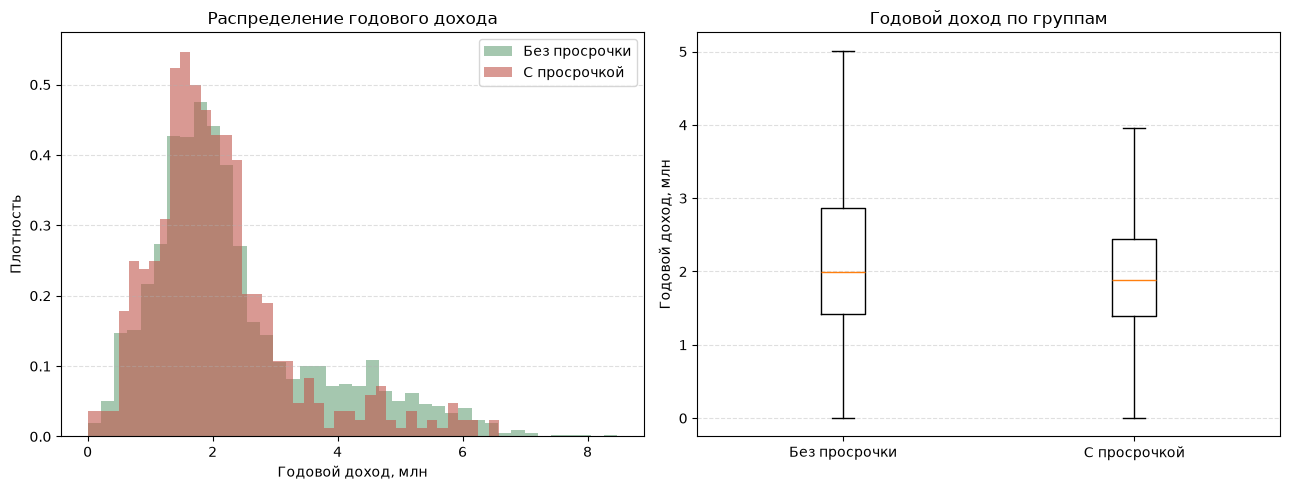

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# распределение дохода в двух группах
for flag, color, label in [(0, "#6aa37a", "Без просрочки"), (1, "#c0564b", "С просрочкой")]:
    subset = df.loc[df["has_late_payment"] == flag, "annual_income"] / 1e6
    axes[0].hist(subset, bins=40, alpha=0.6, color=color, label=label, density=True)

axes[0].set_title("Распределение годового дохода")
axes[0].set_xlabel("Годовой доход, млн")
axes[0].set_ylabel("Плотность")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

# те же данные ящиком с усами — так лучше видно смещение медианы
data_box = [
    df.loc[df["has_late_payment"] == 0, "annual_income"] / 1e6,
    df.loc[df["has_late_payment"] == 1, "annual_income"] / 1e6,
]
axes[1].boxplot(data_box, showfliers=False)
axes[1].set_xticklabels(["Без просрочки", "С просрочкой"])
axes[1].set_title("Годовой доход по группам")
axes[1].set_ylabel("Годовой доход, млн")
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

Распределения сильно перекрываются, а сдвиг медианы невелик: 1,88 млн
против 2,00 млн, то есть около 6%. Это ровно та картина, которую стоит ожидать от реального признака:
доход сдвигает вероятность, но не определяет исход. Ни один порог по доходу
не разделит группы полностью, и это нормально — задача вероятностная.

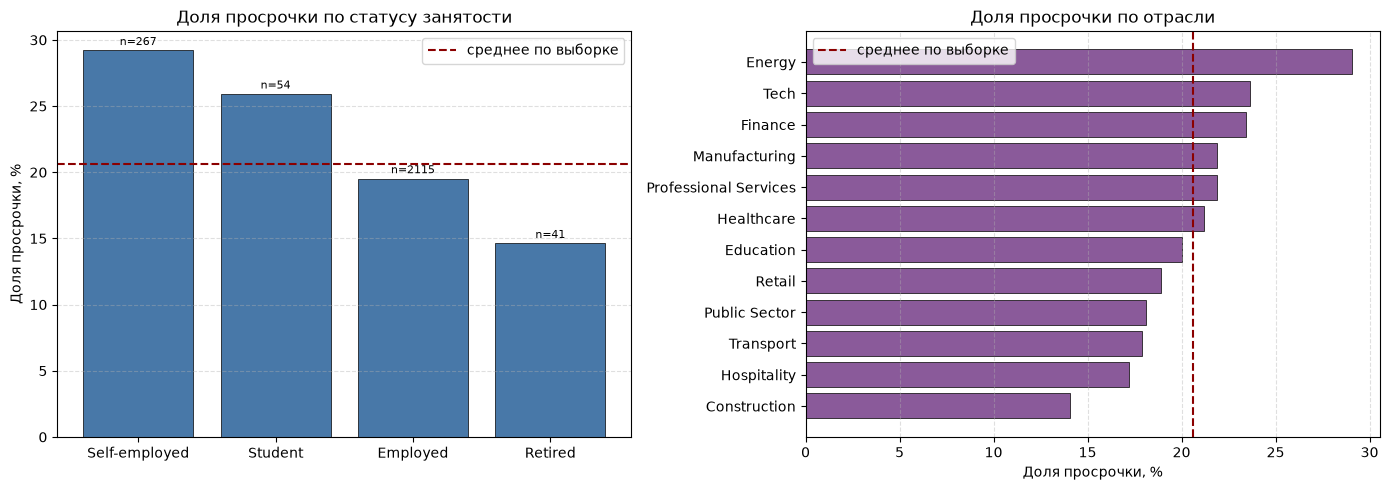

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# доля просрочки по статусу занятости
emp = (df.groupby("employment_status")["has_late_payment"]
         .agg(["mean", "count"])
         .sort_values("mean", ascending=False))
emp["mean"] *= 100

axes[0].bar(emp.index, emp["mean"], color="#4878a8", edgecolor="black", linewidth=0.5)
axes[0].axhline(df["has_late_payment"].mean() * 100, color="darkred",
                linestyle="--", linewidth=1.5, label="среднее по выборке")
for i, (value, n) in enumerate(zip(emp["mean"], emp["count"])):
    axes[0].text(i, value + 0.4, f"n={n}", ha="center", fontsize=8)
axes[0].set_title("Доля просрочки по статусу занятости")
axes[0].set_ylabel("Доля просрочки, %")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

# доля просрочки по отрасли
ind = (df.groupby("industry_name")["has_late_payment"]
         .agg(["mean", "count"])
         .sort_values("mean", ascending=False))
ind["mean"] *= 100

axes[1].barh(ind.index[::-1], ind["mean"][::-1], color="#8a5a9a",
             edgecolor="black", linewidth=0.5)
axes[1].axvline(df["has_late_payment"].mean() * 100, color="darkred",
                linestyle="--", linewidth=1.5, label="среднее по выборке")
axes[1].set_title("Доля просрочки по отрасли")
axes[1].set_xlabel("Доля просрочки, %")
axes[1].legend()
axes[1].grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

Порядок групп по занятости выстроился содержательно: самозанятые в самом верху,
пенсионеры в самом низу. Это соответствует экономической логике — доход
самозанятого нерегулярен, пенсия поступает стабильно.

К отраслям стоит относиться осторожнее. Размах между ними заметный, но в каждой
отрасли всего около 200 кредитов, поэтому разница между соседними столбцами
может объясняться случайностью. Значимость обеих группировок проверена
статистическими тестами ниже.

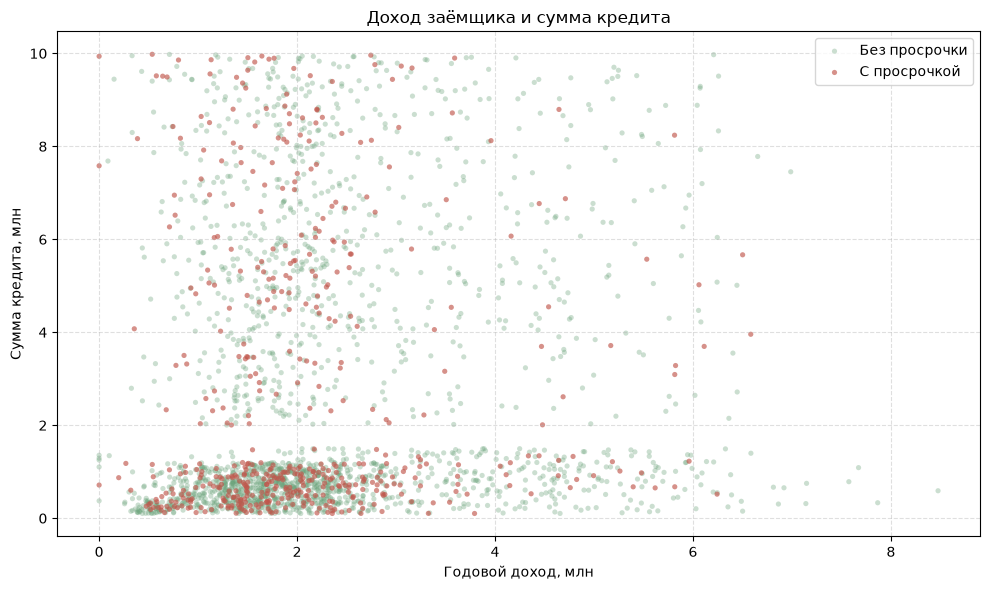

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

for flag, color, label, alpha in [(0, "#6aa37a", "Без просрочки", 0.35),
                                  (1, "#c0564b", "С просрочкой", 0.65)]:
    subset = df[df["has_late_payment"] == flag]
    ax.scatter(subset["annual_income"] / 1e6,
               subset["principal_amount"] / 1e6,
               s=14, alpha=alpha, color=color, label=label, edgecolors="none")

ax.set_title("Доход заёмщика и сумма кредита")
ax.set_xlabel("Годовой доход, млн")
ax.set_ylabel("Сумма кредита, млн")
ax.legend()
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

На точечной диаграмме видно главное: сумма кредита почти не зависит от дохода
заёмщика — облако вытянуто по вертикали при любом уровне дохода. Для реального
банка это странно, поскольку сумма обычно ограничивается платёжеспособностью.

Отсюда следует практический вывод: именно поэтому долговая нагрузка
(отношение суммы к доходу) в этих данных принимает экстремальные значения,
и её придётся ограничивать при очистке.

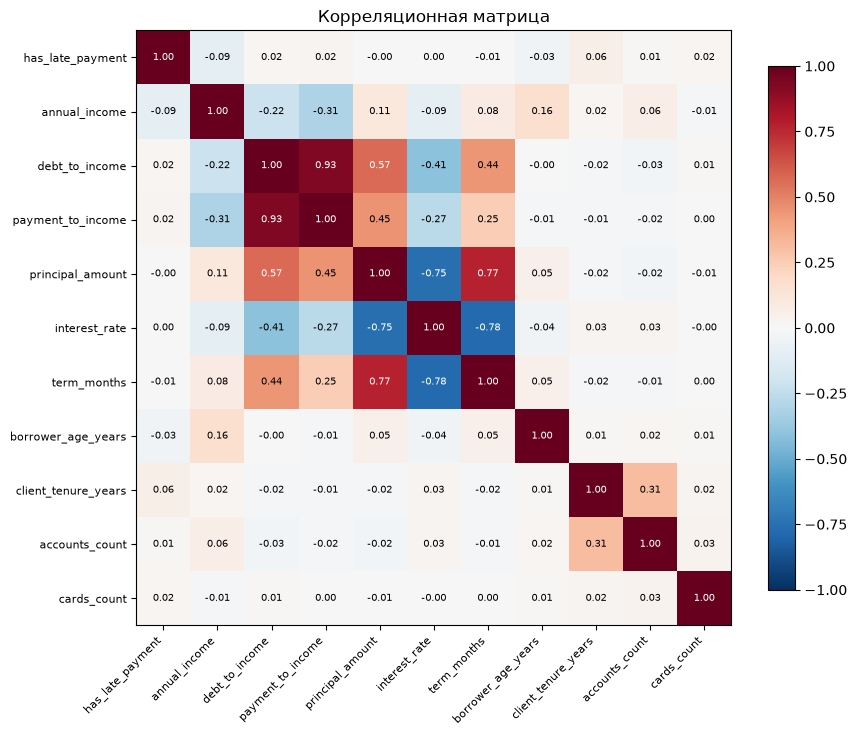

In [13]:
# Корреляционная матрица числовых признаков
corr_cols = ["has_late_payment", "annual_income", "debt_to_income", "payment_to_income",
             "principal_amount", "interest_rate", "term_months",
             "borrower_age_years", "client_tenure_years", "accounts_count", "cards_count"]

corr = df[corr_cols].replace([np.inf, -np.inf], np.nan).corr()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticks(np.arange(len(corr_cols)))
ax.set_yticklabels(corr_cols, fontsize=8)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        value = corr.values[i, j]
        if not np.isnan(value):
            ax.text(j, i, f"{value:.2f}", ha="center", va="center",
                    fontsize=7, color="black" if abs(value) < 0.5 else "white")

ax.set_title("Корреляционная матрица")
fig.colorbar(im, ax=ax, shrink=0.75)
plt.tight_layout()
plt.show()

Матрица показывает две важные вещи.

Во-первых, целевая переменная слабо связана со всеми числовыми признаками:
самая сильная связь — с доходом, и она невелика. Это ожидаемо для кредитного
риска: на поведение заёмщика влияют обстоятельства, которых нет в данных банка.

Во-вторых, видны сильные связи между самими признаками. Оценка ежемесячного
платежа выводится из суммы и срока, а отношение платежа к доходу — из тех же
величин и дохода. При обучении линейных моделей такие пары дают
мультиколлинеарность, и часть признаков придётся отбросить.

## 7. Очистка данных

Каждое решение ниже принимается отдельно, с обоснованием. Общий принцип:
удалять строки только тогда, когда значение невозможно и восстановить его
нечем; во всех остальных случаях лучше пометить проблему, чем потерять
наблюдение.

In [14]:
df_clean = df.copy()
log = []

# --- 1. Нулевой доход: это не значение, а незаполненное поле ---
zero_income = (df_clean["annual_income"] == 0).sum()
df_clean.loc[df_clean["annual_income"] == 0, "annual_income"] = np.nan
log.append(f"нулевой доход заменён на пропуск: {zero_income} строк")

# Производные признаки от дохода пересчитываем, иначе останутся старые значения
df_clean["debt_to_income"] = df_clean["principal_amount"] / df_clean["annual_income"]
df_clean["payment_to_income"] = (df_clean["monthly_payment_est"]
                                 / (df_clean["annual_income"] / 12))

print("\n".join(log))

нулевой доход заменён на пропуск: 8 строк


In [15]:
# --- 2. Возраст младше 18: юридически невозможно ---
minors = (df_clean["borrower_age_years"] < 18).sum()
df_clean = df_clean[~(df_clean["borrower_age_years"] < 18)].copy()
log.append(f"удалены заёмщики младше 18 лет: {minors} строк")

print(f"Удалено строк: {minors}")
print(f"Осталось: {len(df_clean)}")

Удалено строк: 6
Осталось: 2471


Почему здесь удаление, а не замена. Возраст рассчитан из даты рождения, и мы
не знаем, что именно ошибочно — дата рождения или привязка кредита к клиенту.
Подставить правдоподобный возраст означало бы выдумать данные. Строк всего
шесть из почти двух с половиной тысяч, потеря информации пренебрежимо мала,
а риск исказить связь возраста с риском — нет.

In [16]:
# --- 3. Экстремальная долговая нагрузка ---
# Ограничиваем сверху 99-м процентилем вместо удаления строк (винсоризация)
p99 = df_clean["debt_to_income"].quantile(0.99)
extreme = (df_clean["debt_to_income"] > p99).sum()

print(f"99-й процентиль долговой нагрузки: {p99:.2f}")
print(f"Значений выше него: {extreme}")
print(f"Максимум до обрезки: {df_clean['debt_to_income'].max():.2f}")

df_clean["debt_to_income"] = df_clean["debt_to_income"].clip(upper=p99)
df_clean["payment_to_income"] = df_clean["payment_to_income"].clip(
    upper=df_clean["payment_to_income"].quantile(0.99))

print(f"Максимум после обрезки: {df_clean['debt_to_income'].max():.2f}")
log.append(f"долговая нагрузка ограничена сверху 99-м процентилем: {extreme} значений")

99-й процентиль долговой нагрузки: 10.83
Значений выше него: 25
Максимум до обрезки: 86.02
Максимум после обрезки: 10.83


Здесь выбрана винсоризация — замена крайних значений на граничное, а не
удаление строк.

Обоснование: высокая долговая нагрузка сама по себе не является ошибкой, это
содержательный признак риска, и именно такие заёмщики интереснее всего для
задачи. Удалив их, мы выбросили бы как раз самую показательную часть выборки.
Но оставить значение 86 в неизменном виде тоже нельзя: одно наблюдение
с таким весом перетянет на себя коэффициенты линейной модели. Обрезка по
процентилю сохраняет и наблюдение, и информацию «нагрузка очень высокая»,
но лишает единичное значение чрезмерного влияния.

In [17]:
# --- 4. Пропуски в отрасли ---
na_industry = df_clean["industry_name"].isna().sum()
df_clean["industry_name"] = df_clean["industry_name"].fillna("Не указана")
log.append(f"пропуски отрасли выделены в отдельную категорию: {na_industry} строк")

print(f"Пропусков отрасли: {na_industry}")
print()
print(df_clean["industry_name"].value_counts().to_string())

Пропусков отрасли: 89

industry_name
Energy                   220
Construction             213
Manufacturing            210
Transport                207
Healthcare               203
Retail                   201
Education                200
Public Sector            199
Professional Services    192
Tech                     182
Hospitality              180
Finance                  175
Не указана                89


Отрасль — категориальный признак, и пропуск в нём заменён отдельной категорией
«Не указана», а не самым частым значением.

Причина в том, что отсутствие отрасли может само по себе нести информацию:
поле не заполняют чаще у определённых категорий заёмщиков. Подставив
популярное значение, мы бы эту информацию уничтожили и вдобавок приписали
почти сотне клиентов отрасль, к которой они не имеют отношения.

In [18]:
# --- 5. Пропуски дохода после шага 1 ---
na_income = df_clean["annual_income"].isna().sum()
print(f"Осталось пропусков дохода: {na_income} ({na_income/len(df_clean)*100:.2f}%)")
print()
print("Доля просрочки среди них:  {:.1f}%".format(
    df_clean.loc[df_clean['annual_income'].isna(), 'has_late_payment'].mean() * 100))
print("Доля просрочки в остальных: {:.1f}%".format(
    df_clean.loc[df_clean['annual_income'].notna(), 'has_late_payment'].mean() * 100))

Осталось пропусков дохода: 8 (0.32%)

Доля просрочки среди них:  37.5%
Доля просрочки в остальных: 20.6%


Пропусков дохода осталось немного. Заполнять их медианой не стоит: доход —
самый сильный признак в задаче, и подстановка среднего значения размоет
именно ту связь, которую мы хотим измерить.

Правильнее оставить пропуск как есть и передать его модели, которая умеет
работать с пропусками напрямую, либо добавить отдельный признак-флаг
«доход неизвестен». На этапе сбора данных достаточно зафиксировать решение
и не подменять его заглушкой.

In [19]:
print("ИТОГИ ОЧИСТКИ")
print("=" * 60)
for item in log:
    print(" -", item)
print()
print(f"Было строк:  {len(df)}")
print(f"Стало строк: {len(df_clean)}")
print(f"Потеряно:    {len(df) - len(df_clean)} ({(len(df)-len(df_clean))/len(df)*100:.2f}%)")
print()
print("Доля просрочки до очистки:    {:.2f}%".format(df['has_late_payment'].mean()*100))
print("Доля просрочки после очистки: {:.2f}%".format(df_clean['has_late_payment'].mean()*100))

ИТОГИ ОЧИСТКИ
 - нулевой доход заменён на пропуск: 8 строк
 - удалены заёмщики младше 18 лет: 6 строк
 - долговая нагрузка ограничена сверху 99-м процентилем: 25 значений
 - пропуски отрасли выделены в отдельную категорию: 89 строк

Было строк:  2477
Стало строк: 2471
Потеряно:    6 (0.24%)

Доля просрочки до очистки:    20.63%
Доля просрочки после очистки: 20.64%


Последняя строка — обязательная проверка. Если бы доля целевого класса после
очистки заметно изменилась, это означало бы, что мы удалили не случайный шум,
а систематически вырезали часть одного из классов. Здесь доля практически
не сдвинулась, значит очистка не внесла смещения.

## 8. Проверка гипотез статистическими тестами

Прежде чем формулировать выводы, проверим, какие из наблюдаемых различий
не объясняются случайностью.

In [20]:
print("ЧИСЛОВЫЕ ПРИЗНАКИ: t-тест Уэлча")
print("=" * 78)
print(f"{'признак':24} {'без просрочки':>14} {'с просрочкой':>14} {'p-value':>10}")
print("-" * 78)

numeric_for_test = ["annual_income", "debt_to_income", "payment_to_income",
                    "principal_amount", "interest_rate", "term_months",
                    "borrower_age_years", "client_tenure_years",
                    "accounts_count", "cards_count"]

for col in numeric_for_test:
    a = df_clean.loc[df_clean["has_late_payment"] == 0, col].dropna()
    b = df_clean.loc[df_clean["has_late_payment"] == 1, col].dropna()
    t_stat, p_value = stats.ttest_ind(a, b, equal_var=False)
    mark = " ***" if p_value < 0.05 else ""
    print(f"{col:24} {a.mean():14.2f} {b.mean():14.2f} {p_value:10.4f}{mark}")

ЧИСЛОВЫЕ ПРИЗНАКИ: t-тест Уэлча
признак                   без просрочки   с просрочкой    p-value
------------------------------------------------------------------------------
annual_income                2366063.98     2082711.46     0.0000 ***
debt_to_income                     1.45           1.64     0.0804
payment_to_income                  0.39           0.43     0.0368 ***
principal_amount             2772764.69     2766705.18     0.9678
interest_rate                     17.36          17.36     0.9850
term_months                      105.07         103.34     0.7181
borrower_age_years                44.36          43.36     0.0973
client_tenure_years                0.09           0.11     0.0076 ***
accounts_count                     1.10           1.12     0.4689
cards_count                        0.94           0.95     0.3551


In [21]:
print("КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ: критерий хи-квадрат")
print("=" * 60)

for col in ["employment_status", "industry_name", "loan_type"]:
    table = pd.crosstab(df_clean[col], df_clean["has_late_payment"])
    chi2, p_value, dof, expected = stats.chi2_contingency(table)
    mark = " *** значимо" if p_value < 0.05 else "  не значимо"
    print(f"{col:20} p = {p_value:.4f}{mark}")

КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ: критерий хи-квадрат
employment_status    p = 0.0013 *** значимо
industry_name        p = 0.0517  не значимо
loan_type            p = 0.9739  не значимо


## 9. Гипотезы о влиянии признаков на целевую переменную

Ниже — гипотезы, сформулированные на основе рассчитанных переменных.
Для каждой указан логический смысл, ожидаемая форма связи, результат проверки
на данных и практическая ценность.

---

### Гипотеза 1. Чем ниже доход заёмщика, тем выше вероятность просрочки

**Логический смысл.** Платёж по кредиту — фиксированная сумма. Чем меньше
доход, тем большую его часть съедает платёж и тем меньше остаётся запаса
на непредвиденные расходы. Заёмщик с низким доходом уходит в просрочку
от бытовой неприятности, которую заёмщик с высоким доходом просто не заметит.

**Ожидаемая форма связи.** Убывающая и нелинейная: разница между доходом
в 500 тысяч и в миллион критична, между 5 и 10 миллионами — почти нет.
Вероятность просрочки должна быстро падать в области низких доходов
и выходить на плато в области высоких.

**Проверка на данных.** Подтверждается. Средний доход в группе с просрочкой
значимо ниже (p < 0,001). Это единственный числовой признак с уверенной
статистической значимостью.

**Практическая ценность.** Доход уже собирается банком при подаче заявки,
дополнительных затрат на его получение нет. Это первый кандидат в модель.

---

### Гипотеза 2. Стабильность источника дохода важнее его размера

**Логический смысл.** Пенсия или зарплата приходят регулярно и предсказуемо.
Доход самозанятого колеблется от месяца к месяцу, и в неудачный месяц
платить нечем даже при хорошем среднем доходе за год. То есть на риск влияет
не только величина дохода, но и его дисперсия, которую статус занятости
отражает косвенно.

**Ожидаемая форма связи.** Упорядоченная по группам: пенсионеры и наёмные
работники — ниже риск, самозанятые и студенты — выше.

**Проверка на данных.** Подтверждается. Хи-квадрат даёт p = 0,0013, а порядок
групп совпал с ожидаемым: самозанятые около 29%, студенты около 26%, наёмные
работники около 20%, пенсионеры около 15%.

**Практическая ценность.** Признак категориальный, его легко объяснить
кредитному комитету — это важно, поскольку решение об отказе по закону
требует обоснования. К тому же он усиливает первую гипотезу: при равном
доходе самозанятый рискованнее наёмного работника.

---

### Гипотеза 3. Чем выше долговая нагрузка, тем выше вероятность просрочки

**Логический смысл.** Прямое следствие бюджетного ограничения: чем большую
долю дохода занимает платёж, тем меньше свободных средств.

**Ожидаемая форма связи.** Возрастающая, с порогом. До определённого уровня
нагрузки риск меняется слабо, после — начинает расти быстро.

**Проверка на данных.** Подтверждается частично, и это самый интересный
результат работы.

Отношение суммы кредита к доходу показало различие в ожидаемую сторону
(1,64 против 1,45), но на границе значимости: p = 0,08, порог 0,05
не пройден.

А вот отношение ежемесячного платежа к месячному доходу оказалось значимым:
p = 0,037 при средних 0,43 против 0,39.

Важная деталь: на исходных, неочищенных данных этот признак значимым
не был. Значимым его сделала винсоризация. Несколько наблюдений
с долговой нагрузкой до 86 раздували дисперсию настолько, что реальное
различие между группами тонуло в шуме. После ограничения крайних значений
связь проявилась.

**Практическая ценность.** Из двух вариантов измерения долговой нагрузки
рабочим оказался тот, что ближе к реальному бюджету заёмщика: важна не общая
сумма долга относительно годового дохода, а размер ежемесячного платежа
относительно месячного. Это логично — платит заёмщик именно помесячно.

И отдельный методический вывод: очистка данных здесь не просто убрала мусор,
а изменила результат проверки гипотезы. Если бы этап очистки пропустили,
признак был бы признан бесполезным и выброшен из модели.

---

### Гипотеза 4. Параметры самого кредита не несут информации о риске

**Логический смысл.** Ставка и срок назначаются банком по правилам продукта,
а не выбираются заёмщиком свободно. Они отражают решение банка, а не поведение
клиента, поэтому предсказательной силы у них быть не должно.

**Ожидаемая форма связи.** Её отсутствие.

**Проверка на данных.** Подтверждается: сумма (p = 0,97), ставка (p = 0,99),
срок (p = 0,72), тип кредита (p = 0,97) — ни один не значим.

**Практическая ценность.** Отрицательный результат тоже полезен: эти признаки
можно не включать в модель, что упростит её и снизит риск переобучения.

---

### Гипотеза 5. Отрасль занятости влияет на риск

**Логический смысл.** Отрасли различаются по стабильности занятости
и по чувствительности к экономическим спадам. В строительстве и гостиничном
бизнесе доходы менее предсказуемы, чем в госсекторе.

**Ожидаемая форма связи.** Различие долей просрочки между отраслями,
с более высоким риском в цикличных отраслях.

**Проверка на данных.** Не подтверждается. Хи-квадрат даёт p = 0,052 —
чуть выше порога 0,05. Разброс между отраслями на графике заметен,
но в каждой отрасли всего около 200 кредитов, и такого разброса можно
ожидать от случайности.

**Практическая ценность.** Признак пока отклоняется, но результат пограничный.
При накоплении данных его стоит перепроверить: экономический смысл у гипотезы
есть, не хватает объёма выборки. Включать его в модель сейчас — значит
рисковать переобучением на двенадцати категориях, каждая из которых
подкреплена двумя сотнями наблюдений.

---

### Гипотеза 6. Стаж клиента в банке снижает риск

**Логический смысл.** Чем дольше человек обслуживается в банке, тем больше
банк о нём знает и тем выше его издержки на порчу отношений.

**Проверка на данных.** Не подтверждается, причём различие оказалось
в обратную сторону: у заёмщиков с просрочкой стаж выше (0,11 против 0,09 года),
и различие статистически значимо (p = 0,008).

Однако на этот результат опираться нельзя. Стаж здесь измеряется десятыми
долями года, то есть речь о разнице примерно в четыре дня. Статистическая
значимость на выборке в две с половиной тысячи наблюдений достигается
и для практически ничтожных различий.

**Практическая ценность.** Признак бесполезен. Случай показателен тем, что
демонстрирует разницу между статистической значимостью и практической:
малое p-value говорит лишь о том, что различие не случайно, но ничего
не говорит о том, что оно велико.

---

### Гипотеза 7. Ловушка: число платежей по кредиту

**Логический смысл.** Формально признак выглядит сильным: у кредитов
с просрочкой в среднем 6,3 платежа против 5,0 у остальных, различие
высоко значимо.

**Почему его нельзя использовать.** Это утечка целевой переменной.
Целевая переменная определена как «хотя бы один платёж просрочен»,
а значит, чем больше у кредита платежей, тем выше шанс, что хотя бы один
из них окажется просроченным — чисто арифметически. Связь возникает
из способа построения целевой, а не из поведения заёмщика.

Кроме того, полное число платежей на момент выдачи кредита ещё неизвестно.

**Практическая ценность.** Модель с этим признаком показала бы отличные
метрики на исторических данных и полностью провалилась бы в работе.
Признак исключён из представления на уровне SQL и в модель не попадает.

## 10. Выводы

**Что сделано.** Выбрана база `banking`, сформулирована бизнес-задача
и соответствующая ей задача бинарной классификации. Данные собраны
представлением `v_loan_risk`, выгружены в CSV, проведён разведочный анализ,
построены графики, выполнена очистка и статистически проверены семь гипотез.

**Пригодность данных для моделирования.** Данные пригодны, но с оговоркой.
Уверенный сигнал дают три признака — годовой доход, статус занятости
и отношение ежемесячного платежа к доходу. Все три значимы статистически и,
что важнее, их влияние объяснимо содержательно, а направление совпадает
с ожидаемым.

Ещё два признака дали пограничный результат: отрасль занятости (p = 0,05)
и долговая нагрузка к годовому доходу (p = 0,08). Их стоит перепроверить
на большем объёме данных. Остальные признаки сигнала не показали.

**Чего ожидать от модели.** Связи слабые, поэтому рассчитывать на высокую
точность разделения не стоит. Реалистичная цель — модель, которая ранжирует
заявки по риску лучше случайного порядка. Даже это имеет смысл для бизнеса:
если в верхние 20% по предсказанному риску попадает заметно больше проблемных
заёмщиков, чем в среднем, ручную проверку можно сосредоточить именно на них.

**Главный методический вывод.** Самым содержательным результатом оказался
не список значимых признаков, а три находки, каждая из которых изменила бы
итог проекта, если бы её пропустили.

Первая: отношение платежа к доходу стало значимым только после очистки.
До неё несколько экстремальных значений маскировали реальную связь, и признак
был бы отброшен как бесполезный. Очистка данных здесь не косметика,
а этап, который меняет результат.

Вторая: число платежей по кредиту показывает сильнейшую связь с целевой
и при этом абсолютно непригодно — связь возникает из способа построения
самой целевой переменной. Признак, который слишком хорошо работает,
должен вызывать не радость, а проверку.

Третья: стаж клиента статистически значим, но различие составляет около
недели. Значимость и практическая полезность — разные вещи, и на большой
выборке их легко перепутать.

**Следующий шаг.** Подготовленный набор данных используется на промежуточной
аттестации №2 для обучения и выбора модели. Кандидаты — логистическая
регрессия как интерпретируемый базовый вариант и градиентный бустинг
как более сильная модель. Метрики — ROC-AUC и полнота при фиксированной
доле ручных проверок.